In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

print("Day 37 libraries imported successfully!")

Day 37 libraries imported successfully!


In [4]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 5.7 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/11.3 MB 5.5 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 5.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.3 MB 5.4 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.3 MB 5.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.3 MB 5.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.1/11.3 MB 5.4 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 5.5 MB/s eta 0:00:01
   ------------------------------- -------- 8.9/11.3 MB 5.1 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.3 MB 5.0 MB/s eta 0:00:01
   ------------------------------------ --- 10.5/11.3 MB 5.0 MB/s eta 0:00:01
   -

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

print("Day 37 libraries imported successfully!")

Day 37 libraries imported successfully!


In [7]:
df = pd.read_csv("../cleaned_dataset.csv")

print("Historical sales dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Historical sales dataset loaded successfully!
Dataset shape: (51290, 23)

Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])

print("Order date converted successfully!")
print("Date range:")
print(df["order_date"].min(), "to", df["order_date"].max())

display(df[["order_date", "sales"]].head())

Order date converted successfully!
Date range:
2011-01-01 00:00:00 to 2014-12-31 00:00:00


,order_date,sales
0,2011-01-01,408.0
1,2011-01-01,120.0
2,2011-01-01,66.0
3,2011-01-01,45.0
4,2011-01-01,114.0


In [9]:
daily_revenue = (
    df.groupby("order_date")["sales"]
    .sum()
    .reset_index()
)

daily_revenue.columns = ["date", "revenue"]

daily_revenue = daily_revenue.sort_values("date")

print("Daily revenue time series created successfully!")
print("Number of days:", len(daily_revenue))

display(daily_revenue.head(10))

Daily revenue time series created successfully!
Number of days: 1430


,date,revenue
0,2011-01-01,808.0
1,2011-01-02,314.0
2,2011-01-03,4502.0
3,2011-01-04,2809.0
4,2011-01-05,3664.0
5,2011-01-06,623.0
6,2011-01-07,7122.0
7,2011-01-08,6295.0
8,2011-01-09,815.0
9,2011-01-10,6793.0


In [10]:
daily_revenue = (
    daily_revenue
    .set_index("date")
    .asfreq("D", fill_value=0)
    .reset_index()
)

print("Continuous daily revenue series created successfully!")

print("\nDate range:")
print(daily_revenue["date"].min(), "to", daily_revenue["date"].max())

print("\nDataset shape:")
print(daily_revenue.shape)

print("\nMissing values:")
print(daily_revenue.isnull().sum())

display(daily_revenue.head(10))

Continuous daily revenue series created successfully!

Date range:
2011-01-01 00:00:00 to 2014-12-31 00:00:00

Dataset shape:
(1461, 2)

Missing values:
date       0
revenue    0
dtype: int64


,date,revenue
0,2011-01-01,808.0
1,2011-01-02,314.0
2,2011-01-03,4502.0
3,2011-01-04,2809.0
4,2011-01-05,3664.0
5,2011-01-06,623.0
6,2011-01-07,7122.0
7,2011-01-08,6295.0
8,2011-01-09,815.0
9,2011-01-10,6793.0


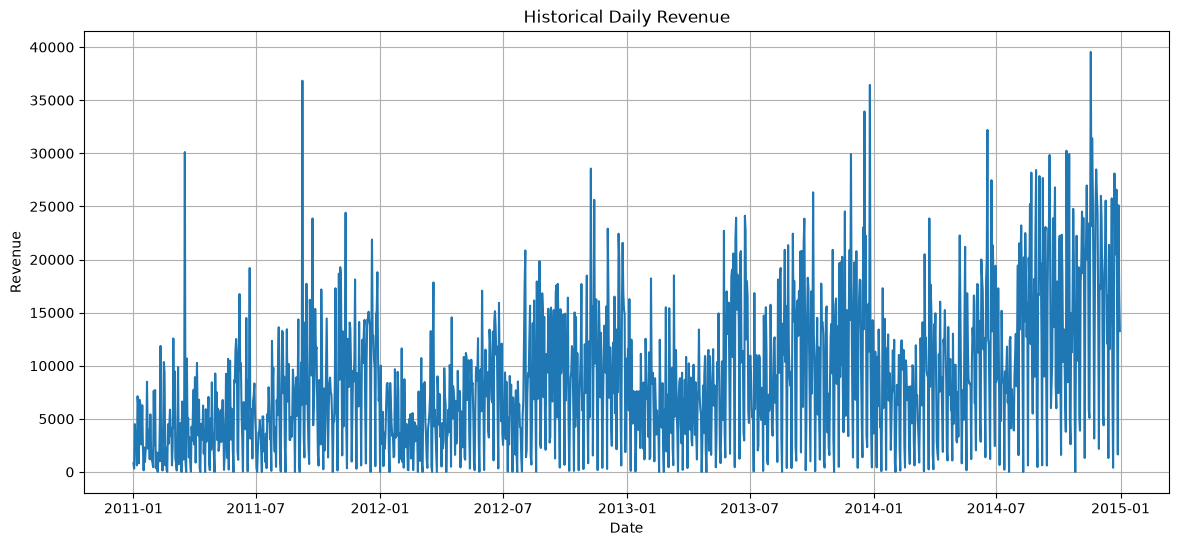

Historical revenue trend plotted successfully!


In [11]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_revenue["date"],
    daily_revenue["revenue"]
)

plt.title("Historical Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

print("Historical revenue trend plotted successfully!")

In [12]:
daily_revenue["rolling_7_day"] = (
    daily_revenue["revenue"]
    .rolling(window=7)
    .mean()
)

print("7-day rolling average calculated successfully!")

display(
    daily_revenue[
        ["date", "revenue", "rolling_7_day"]
    ].head(10)
)

7-day rolling average calculated successfully!


,date,revenue,rolling_7_day
0,2011-01-01,808.0,NaN
1,2011-01-02,314.0,NaN
2,2011-01-03,4502.0,NaN
3,2011-01-04,2809.0,NaN
4,2011-01-05,3664.0,NaN
5,2011-01-06,623.0,NaN
6,2011-01-07,7122.0,2834.571429
7,2011-01-08,6295.0,3618.428571
8,2011-01-09,815.0,3690.000000
9,2011-01-10,6793.0,4017.285714


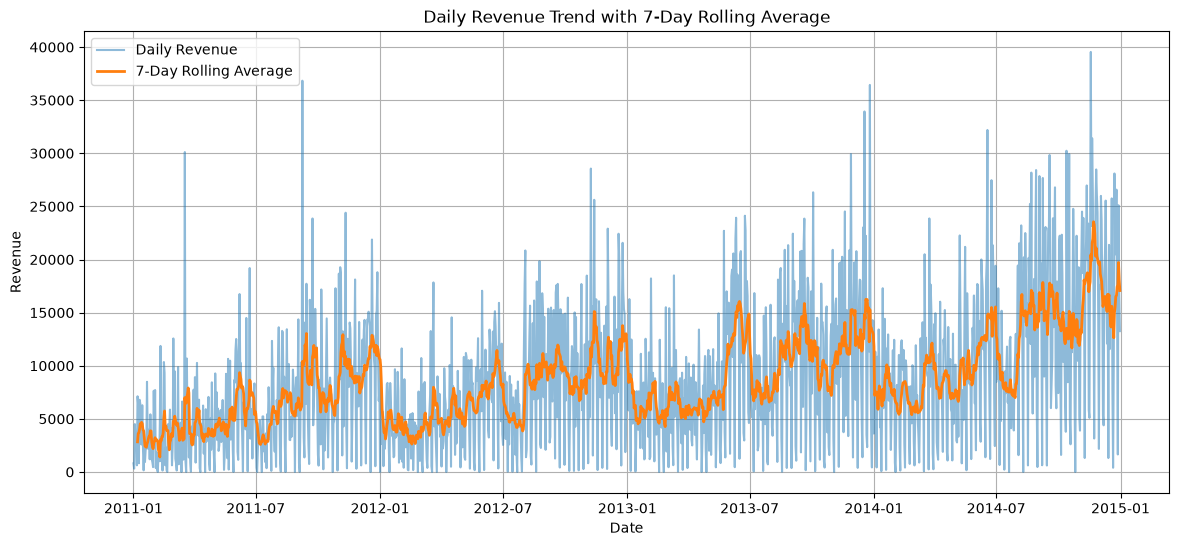

Revenue trend with rolling average plotted successfully!


In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_revenue["date"],
    daily_revenue["revenue"],
    label="Daily Revenue",
    alpha=0.5
)

plt.plot(
    daily_revenue["date"],
    daily_revenue["rolling_7_day"],
    label="7-Day Rolling Average",
    linewidth=2
)

plt.title("Daily Revenue Trend with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

print("Revenue trend with rolling average plotted successfully!")

In [14]:
monthly_revenue = (
    df.groupby(df["order_date"].dt.to_period("M"))["sales"]
    .sum()
    .reset_index()
)

monthly_revenue["order_date"] = (
    monthly_revenue["order_date"].dt.to_timestamp()
)

monthly_revenue.columns = ["month", "revenue"]

monthly_revenue = monthly_revenue.sort_values("month")

print("Monthly revenue data created successfully!")
print("Number of months:", len(monthly_revenue))

display(monthly_revenue.head(10))

Monthly revenue data created successfully!
Number of months: 48


,month,revenue
0,2011-01-01,98902.0
1,2011-02-01,91152.0
2,2011-03-01,145726.0
3,2011-04-01,116927.0
4,2011-05-01,146762.0
5,2011-06-01,215214.0
6,2011-07-01,115518.0
7,2011-08-01,207570.0
8,2011-09-01,290230.0
9,2011-10-01,199070.0


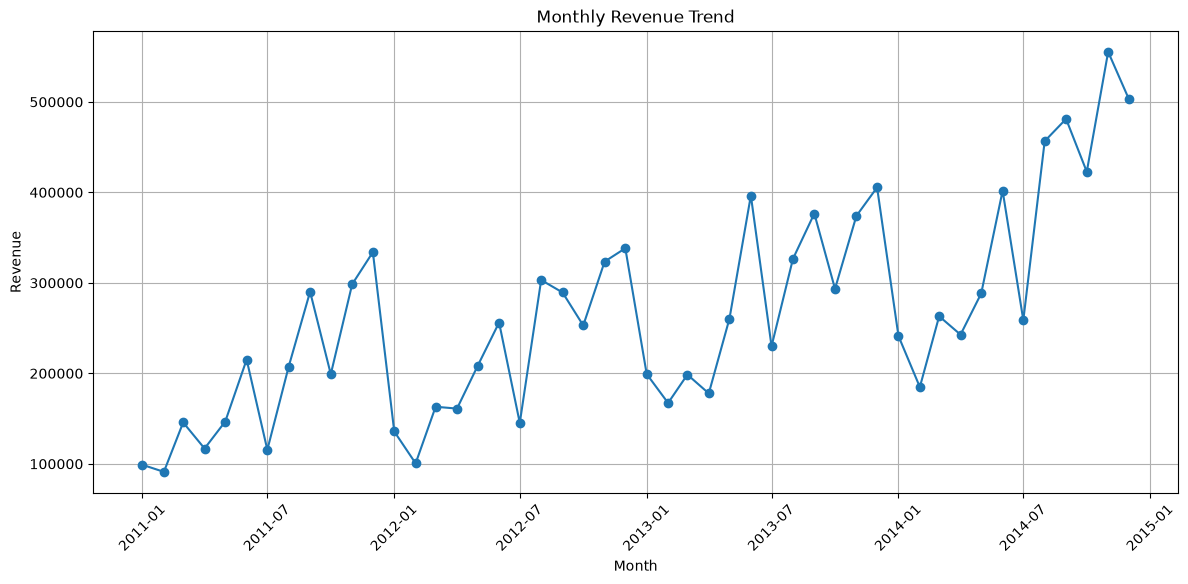

Monthly revenue trend plotted successfully!


In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

print("Monthly revenue trend plotted successfully!")

In [16]:
revenue_series = daily_revenue.set_index("date")["revenue"]

test_days = 30

train_revenue = revenue_series.iloc[:-test_days]
test_revenue = revenue_series.iloc[-test_days:]

print("Training and testing data created successfully!")

print("\nTraining period:")
print(train_revenue.index.min(), "to", train_revenue.index.max())

print("\nTesting period:")
print(test_revenue.index.min(), "to", test_revenue.index.max())

print("\nTraining days:", len(train_revenue))
print("Testing days:", len(test_revenue))

Training and testing data created successfully!

Training period:
2011-01-01 00:00:00 to 2014-12-01 00:00:00

Testing period:
2014-12-02 00:00:00 to 2014-12-31 00:00:00

Training days: 1431
Testing days: 30


In [17]:
model = ARIMA(
    train_revenue,
    order=(1, 1, 1)
)

model_fit = model.fit()

print("ARIMA model trained successfully!")
print(model_fit.summary())

C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA model trained successfully!
                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                 1431
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -14405.073
Date:                Thu, 01 Oct 2026   AIC                          28816.146
Time:                        19:10:19   BIC                          28831.942
Sample:                    01-01-2011   HQIC                         28822.045
                         - 12-01-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1268      0.026      4.926      0.000       0.076       0.177
ma.L1         -0.9481      0.008   -115.498      0.000      -0.964      -0.932
sigma2      3.287e

In [18]:
test_forecast = model_fit.forecast(steps=len(test_revenue))

# Revenue cannot be negative
test_forecast = np.maximum(test_forecast, 0)

print("30-day test forecast generated successfully!")

display(
    pd.DataFrame({
        "actual_revenue": test_revenue.values,
        "predicted_revenue": test_forecast
    }).head(10)
)

30-day test forecast generated successfully!


,actual_revenue,predicted_revenue
2014-12-02,17211.0,17863.246125
2014-12-03,25988.0,17900.168919
2014-12-04,23723.0,17904.849815
2014-12-05,17065.0,17905.443237
2014-12-06,5284.0,17905.518468
2014-12-07,4390.0,17905.528006
2014-12-08,18619.0,17905.529215
2014-12-09,20607.0,17905.529368
2014-12-10,25546.0,17905.529387
2014-12-11,19210.0,17905.529390


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    test_revenue,
    test_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test_revenue,
        test_forecast
    )
)

print("Forecast evaluation completed successfully!")

print("\nMean Absolute Error (MAE):")
print(round(mae, 2))

print("\nRoot Mean Squared Error (RMSE):")
print(round(rmse, 2))

Forecast evaluation completed successfully!

Mean Absolute Error (MAE):
6452.53

Root Mean Squared Error (RMSE):
8111.47


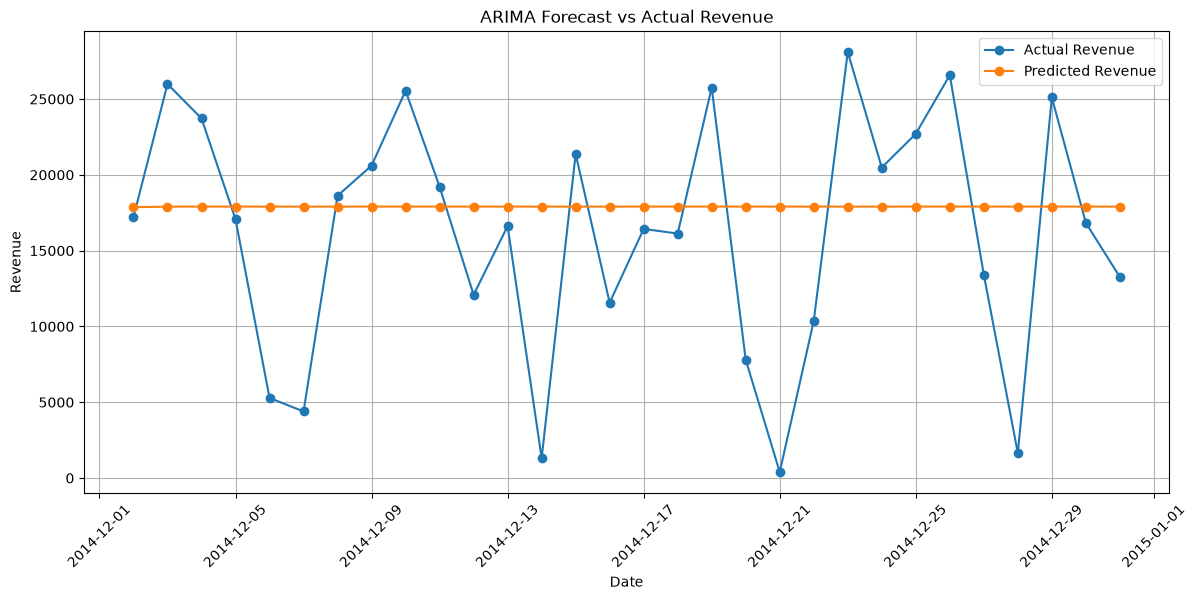

Actual vs predicted revenue comparison plotted successfully!


In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_revenue.index,
    test_revenue.values,
    label="Actual Revenue",
    marker="o"
)

plt.plot(
    test_revenue.index,
    test_forecast,
    label="Predicted Revenue",
    marker="o"
)

plt.title("ARIMA Forecast vs Actual Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

print("Actual vs predicted revenue comparison plotted successfully!")

In [21]:
full_revenue = daily_revenue.set_index("date")["revenue"]

final_model = ARIMA(
    full_revenue,
    order=(1, 1, 1)
)

final_model_fit = final_model.fit()

print("Final ARIMA model trained on complete historical data!")

C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Final ARIMA model trained on complete historical data!


In [22]:
future_forecast = final_model_fit.forecast(steps=30)

# Revenue cannot be negative
future_forecast = np.maximum(future_forecast, 0)

last_date = full_revenue.index.max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_revenue = pd.DataFrame({
    "date": future_dates,
    "predicted_revenue": future_forecast
})

print("Next 30-day revenue forecast generated successfully!")

display(future_revenue.head(10))

Next 30-day revenue forecast generated successfully!


C:\Users\arjun\AppData\Local\Temp\ipykernel_12968\2812103479.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  start=last_date + pd.Timedelta(days=1),


,date,predicted_revenue
2015-01-01,2015-01-01,16066.895856
2015-01-02,2015-01-02,16433.089335
2015-01-03,2015-01-03,16480.829683
2015-01-04,2015-01-04,16487.053553
2015-01-05,2015-01-05,16487.864954
2015-01-06,2015-01-06,16487.970736
2015-01-07,2015-01-07,16487.984526
2015-01-08,2015-01-08,16487.986324
2015-01-09,2015-01-09,16487.986559
2015-01-10,2015-01-10,16487.986589


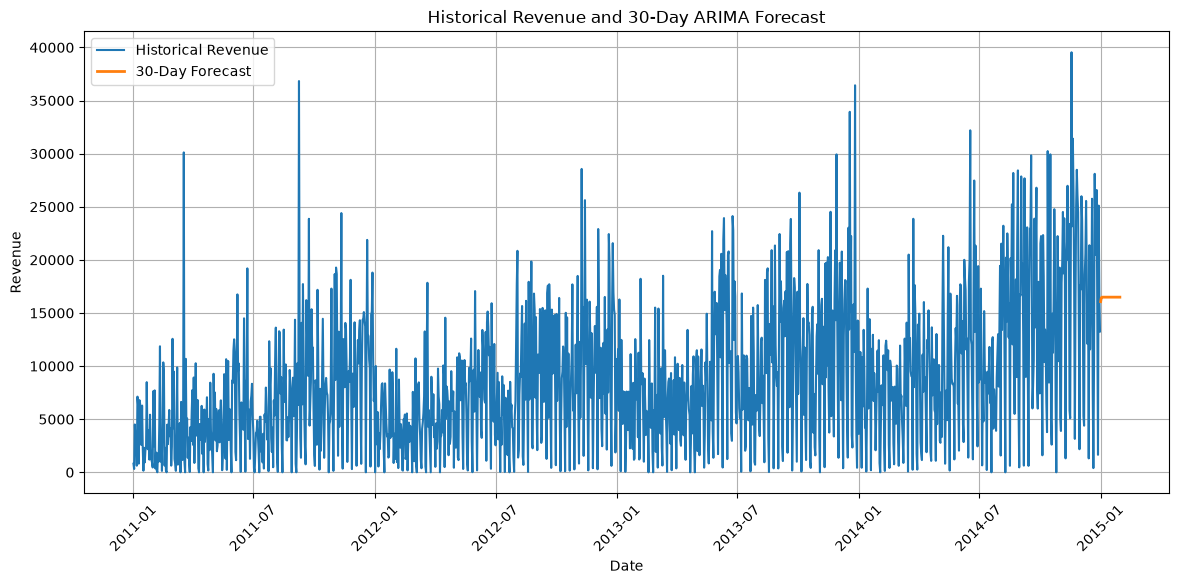

30-day revenue forecast plotted successfully!


In [23]:
plt.figure(figsize=(14, 6))

# Historical revenue
plt.plot(
    full_revenue.index,
    full_revenue.values,
    label="Historical Revenue"
)

# Future forecast
plt.plot(
    future_revenue["date"],
    future_revenue["predicted_revenue"],
    label="30-Day Forecast",
    linewidth=2
)

plt.title("Historical Revenue and 30-Day ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

print("30-day revenue forecast plotted successfully!")

In [24]:
historical_average = full_revenue.mean()

forecast_average = future_revenue["predicted_revenue"].mean()

forecast_total = future_revenue["predicted_revenue"].sum()

forecast_difference = forecast_average - historical_average

forecast_percentage_change = (
    forecast_difference / historical_average
) * 100

print("Revenue forecast summary calculated successfully!")

print("\nHistorical average daily revenue:")
print(round(historical_average, 2))

print("\nForecast average daily revenue:")
print(round(forecast_average, 2))

print("\nPredicted revenue for next 30 days:")
print(round(forecast_total, 2))

print("\nDifference from historical average:")
print(round(forecast_difference, 2))

print("\nPercentage difference:")
print(round(forecast_percentage_change, 2), "%")

Revenue forecast summary calculated successfully!

Historical average daily revenue:
8653.6

Forecast average daily revenue:
16471.85

Predicted revenue for next 30 days:
494155.38

Difference from historical average:
7818.25

Percentage difference:
90.35 %


In [25]:
future_revenue["predicted_revenue"] = (
    future_revenue["predicted_revenue"].round(2)
)

future_revenue.to_csv(
    "revenue_30_day_forecast.csv",
    index=False
)

print("30-day revenue forecast saved successfully!")
print("File: revenue_30_day_forecast.csv")

display(future_revenue.head(10))

30-day revenue forecast saved successfully!
File: revenue_30_day_forecast.csv


,date,predicted_revenue
2015-01-01,2015-01-01,16066.90
2015-01-02,2015-01-02,16433.09
2015-01-03,2015-01-03,16480.83
2015-01-04,2015-01-04,16487.05
2015-01-05,2015-01-05,16487.86
2015-01-06,2015-01-06,16487.97
2015-01-07,2015-01-07,16487.98
2015-01-08,2015-01-08,16487.99
2015-01-09,2015-01-09,16487.99
2015-01-10,2015-01-10,16487.99


In [26]:
evaluation_summary = pd.DataFrame({
    "metric": [
        "MAE",
        "RMSE"
    ],
    "value": [
        round(mae, 2),
        round(rmse, 2)
    ]
})

evaluation_summary.to_csv(
    "revenue_forecast_evaluation.csv",
    index=False
)

print("Forecast evaluation results saved successfully!")
print("File: revenue_forecast_evaluation.csv")

display(evaluation_summary)

Forecast evaluation results saved successfully!
File: revenue_forecast_evaluation.csv


,metric,value
0,MAE,6452.53
1,RMSE,8111.47


In [27]:
report = f"""
# Day 37 — Business Revenue Forecasting Report

## Objective

The objective of this analysis was to forecast future business revenue
using historical sales data and a time series forecasting model.

## Data Preparation

The historical sales dataset was converted into a daily revenue time series
by grouping sales by order date.

Missing dates were added to create a continuous daily timeline, with zero
revenue used for dates without recorded sales.

## Forecasting Method

An ARIMA(1,1,1) model was used as the baseline forecasting model.

The historical data was divided into training and testing periods.
The final model was then trained using the complete historical dataset
to forecast revenue for the next 30 days.

## Model Evaluation

Mean Absolute Error (MAE): {mae:.2f}

Root Mean Squared Error (RMSE): {rmse:.2f}

Lower error values indicate smaller forecasting errors.

## Future Revenue Forecast

Average historical daily revenue: {historical_average:.2f}

Average predicted daily revenue: {forecast_average:.2f}

Predicted revenue for the next 30 days: {forecast_total:.2f}

Percentage difference from historical average:
{forecast_percentage_change:.2f}%

## Business Implications

Revenue forecasting can support business planning by providing an estimate
of future revenue levels.

Forecast information can help businesses with:

- Financial planning
- Budget preparation
- Resource allocation
- Inventory planning
- Sales target planning
- Monitoring expected revenue changes

## Risks and Limitations

The ARIMA(1,1,1) model used in this project is a baseline model.

The forecast may be affected by:

- Seasonal business patterns
- Promotions and discounts
- Unexpected market changes
- Changes in customer behavior
- Limited historical information
- Unusual sales events

The forecast should therefore be treated as an estimate rather than a
guaranteed future revenue value.

## Future Improvements

Future versions could compare ARIMA with other forecasting methods such as:

- SARIMA
- Prophet
- Exponential Smoothing

Additional improvements could include seasonal analysis, external business
variables, longer historical data, and prediction confidence intervals.

## Conclusion

This project demonstrates how historical revenue data can be transformed
into a time series and used to generate a 30-day revenue forecast.

The analysis also shows why forecasting accuracy, business context, and
model limitations are important when using forecasts for decision-making.
"""

with open("business_forecasting_report.md", "w", encoding="utf-8") as file:
    file.write(report)

print("Business forecasting report created successfully!")
print("File: business_forecasting_report.md")

Business forecasting report created successfully!
File: business_forecasting_report.md


In [28]:
import os

day37_files = os.listdir(".")

print("Day 37 files:")
for file in day37_files:
    print("✓", file)

Day 37 files:
✓ business_forecasting_report.md
✓ day37.ipynb
✓ README.md
✓ revenue_30_day_forecast.csv
✓ revenue_forecast_evaluation.csv
